
X shape: (1511, 30, 63)
y shape: (1511,)
Classes: ['1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21' '22'
 '23' '24' '25' '26' '27' '28' '29' '3' '30' '4' '5' '6' '7' '8' '9']
X_train: (1208, 30, 63)
X_test: (303, 30, 63)
Jumlah class: 30


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 30, 63)]             0         []                            
                                                                                                  
 bidirectional (Bidirection  (None, 30, 256)              196608    ['input_1[0][0]']             
 al)                                                                                              
                                                                                                  
 dropout (Dropout)           (No

D:\Labjar\python\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


76/76 [==============================] - ETA: 0s - loss: 1.1091 - accuracy: 0.6457
Epoch 2: val_accuracy improved from 0.50165 to 0.88779, saving model to model_angka_video_laptop.h5
76/76 [==============================] - 5s 70ms/step - loss: 1.1091 - accuracy: 0.6457 - val_loss: 0.3333 - val_accuracy: 0.8878
Epoch 3/100
75/76 [============================>.] - ETA: 0s - loss: 0.4063 - accuracy: 0.8908
Epoch 3: val_accuracy did not improve from 0.88779
76/76 [==============================] - 5s 69ms/step - loss: 0.4060 - accuracy: 0.8907 - val_loss: 0.4706 - val_accuracy: 0.8284
Epoch 4/100
76/76 [==============================] - ETA: 0s - loss: 0.3892 - accuracy: 0.8907
Epoch 4: val_accuracy improved from 0.88779 to 0.91419, saving model to model_angka_video_laptop.h5
76/76 [==============================] - 7s 87ms/step - loss: 0.3892 - accuracy: 0.8907 - val_loss: 0.2671 - val_accuracy: 0.9142
Epoch 5/100
76/76 [==============================] - ETA: 0s - loss: 0.2117 - accuracy

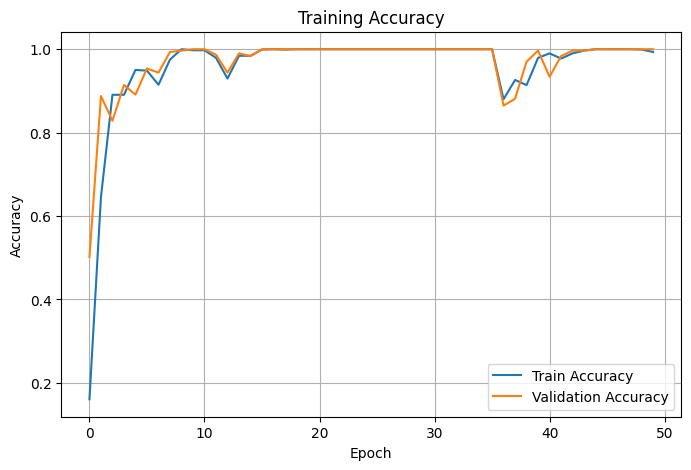

In [ ]:
#LSTM (Long Short-Term Memory)
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense,
    Dropout, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =========================
# PATH DATA
# =========================
DATA_PATH = "extracted_number_data"
X_PATH = os.path.join(DATA_PATH, "X.npy")
Y_PATH = os.path.join(DATA_PATH, "y.npy")
ENCODER_PATH = os.path.join(DATA_PATH, "label_encoder.pkl")

MODEL_OUTPUT = "model_angka_video_laptop.h5"
ENCODER_OUTPUT = "label_encoder_angka_video.pkl"

# =========================
# LOAD DATA
# =========================
X = np.load(X_PATH)
y = np.load(Y_PATH)

with open(ENCODER_PATH, "rb") as f:
    label_encoder = pickle.load(f)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", label_encoder.classes_)

num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Jumlah class:", num_classes)

# =========================
# MODEL BiLSTM + ATTENTION
# =========================
input_layer = Input(shape=(X.shape[1], X.shape[2]))

x = Bidirectional(LSTM(128, return_sequences=True))(input_layer)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

attention = Attention()([x, x])
x = GlobalAveragePooling1D()(attention)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)

output_layer = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# CALLBACK
# =========================
checkpoint = ModelCheckpoint(
    MODEL_OUTPUT,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

# =========================
# TRAINING
# =========================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

# =========================
# EVALUASI
# =========================
loss, acc = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", acc)

# =========================
# CLASSIFICATION REPORT
# =========================
y_pred = model.predict(X_test)

y_pred_label = np.argmax(y_pred, axis=1)
y_true_label = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_true_label,
    y_pred_label,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_label, y_pred_label))

# =========================
# SIMPAN LABEL ENCODER
# =========================
with open(ENCODER_OUTPUT, "wb") as f:
    pickle.dump(label_encoder, f)

print("\nFile berhasil disimpan:")
print("-", MODEL_OUTPUT)
print("-", ENCODER_OUTPUT)

# =========================
# GRAFIK AKURASI
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()